# **Exercise 2 Graph Neural Networks**
##--3079231

**Datasets:** London Output Area (OA) dataset

**Task:** build a Graph Neural Network model that predicts PM2.5 concentration for each Output Area in London.

## **1. Load and explore the dataset**

In [1]:
# Install libraries
!pip install torch-geometric geopandas libpysal

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.0 MB/s eta 0:00:00


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Read the dataset and print initial summary
gdf = gpd.read_file("AssignmentData-LondonPM25Prediction.geojson")
print(gdf.shape)
print(gdf.columns.tolist())
gdf.head()

(25053, 63)
['oa_code', 'PM25', 'k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k009_PCT', 'k010_PCT', 'k011_PCT', 'k012_PCT', 'k013_PCT', 'k014_PCT', 'k015_PCT', 'k016_PCT', 'k017_PCT', 'k018_PCT', 'k019_PCT', 'k020_PCT', 'k021_PCT', 'k022_PCT', 'k023_PCT', 'k024_PCT', 'k025_PCT', 'k026_PCT', 'k027_PCT', 'k028_PCT', 'k029_PCT', 'k030_PCT', 'k031_PCT', 'k032_PCT', 'k033_PCT', 'k034_PCT', 'k035_RATIO', 'k036_PCT', 'k037_PCT', 'k038_PCT', 'k039_PCT', 'k040_PCT', 'k041_PCT', 'k042_PCT', 'k043_PCT', 'k044_PCT', 'k045_PCT', 'k046_PCT', 'k047_PCT', 'k048_PCT', 'k049_PCT', 'k050_PCT', 'k051_PCT', 'k052_PCT', 'k053_PCT', 'k054_PCT', 'k055_PCT', 'k056_PCT', 'k057_PCT', 'k058_PCT', 'k059_PCT', 'k060_PCT', 'geometry']


,oa_code,PM25,k001_PCT,k002_PCT,k003_PCT,k004_PCT,k005_PCT,k006_PCT,k007_RATIO,k008_PCT,...,k052_PCT,k053_PCT,k054_PCT,k055_PCT,k056_PCT,k057_PCT,k058_PCT,k059_PCT,k060_PCT,geometry
0,E00023264,16.037363,0.655567,0.733280,0.788337,0.809438,0.616867,0.048672,0.497994,0.116873,...,0.801915,0.574316,0.565354,0.693873,0.607090,0.478002,0.509235,0.638862,0.662914,"MULTIPOLYGON (((527635.452 171810.058, 527495...."
1,E00003359,15.571575,0.747233,0.539689,0.833211,0.720010,0.659997,0.155885,0.389216,0.387319,...,0.731722,0.346726,0.750254,0.730786,0.669715,0.548814,0.621092,0.667940,0.558571,"MULTIPOLYGON (((543581.516 171132.486, 543704 ..."
2,E00023266,16.068834,0.689326,0.758308,0.780265,0.787414,0.633875,0.151961,0.542225,0.000000,...,0.789704,0.603182,0.551503,0.630910,0.562070,0.614731,0.500493,0.624021,0.682385,"MULTIPOLYGON (((526613.539 171839.165, 526546...."
3,E00020264,18.205215,0.749280,0.701306,0.841211,0.773311,0.432955,0.000000,0.480711,0.000000,...,0.712008,0.454649,0.413096,0.740138,0.831888,0.726281,0.377247,0.517599,0.540406,"MULTIPOLYGON (((533563.521 179695.146, 533351...."
4,E00023263,16.128491,0.716956,0.743201,0.823621,0.783315,0.621155,0.073256,0.532274,0.000000,...,0.752003,0.656612,0.372115,0.741299,0.555038,0.692244,0.524108,0.657307,0.614341,"MULTIPOLYGON (((527822 172020, 527979 171903.0..."


In [4]:
# Basic Statistics
print(gdf.shape)
print(gdf['PM25'].describe())

(25053, 63)
count    25053.000000
mean        15.975608
std          0.783971
min         14.283266
25%         15.403583
50%         15.846878
75%         16.428663
max         21.100099
Name: PM25, dtype: float64


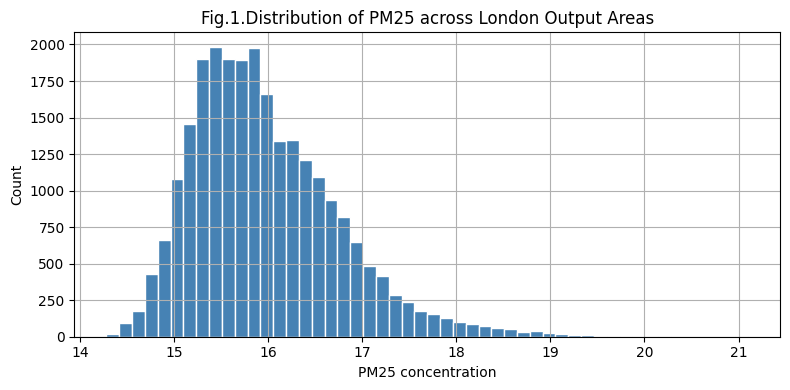

In [5]:
# PM2.5 Distribution Histogram
fig, ax = plt.subplots(figsize=(8, 4))
gdf['PM25'].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Fig.1.Distribution of PM25 across London Output Areas')
ax.set_xlabel('PM25 concentration')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Figure 1:** The histogram shows that PM2.5 values range from approximately 14.3 to 21.1 μg/m³, with a mean of 15.97 and standard deviation of 0.78. The distribution is right-skewed, with the majority of Output Areas concentrated between 15 and 17 μg/m³. A small number of areas exhibit significantly elevated PM2.5 levels above 18 μg/m³, likely corresponding to high-traffic zones in central London. This skewness suggests that extreme pollution values may be harder for the model to predict accurately.

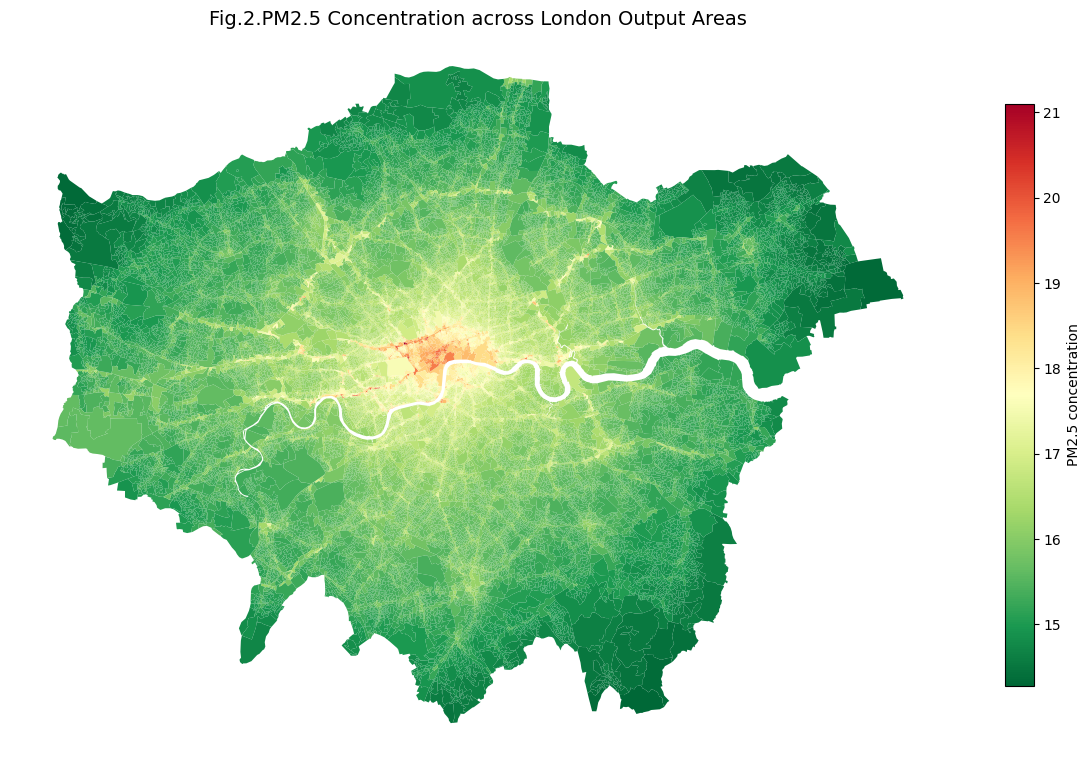

In [6]:
# PM2.5 Distribution Map
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(column='PM25', cmap='RdYlGn_r', legend=True,
         legend_kwds={'label': 'PM2.5 concentration', 'shrink': 0.6},
         ax=ax)
ax.set_title('Fig.2.PM2.5 Concentration across London Output Areas', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

**Figure 2:** The spatial map reveals a clear centre-periphery gradient in PM2.5 concentration across London. The highest pollution levels (above 18 μg/m³) are concentrated in central London, particularly around the City of London and the Thames corridor, where traffic density and urban activity are highest. Pollution levels decrease progressively towards the outer boroughs, with suburban and green belt areas showing the lowest concentrations (around 15 μg/m³).

This strong spatial autocorrelation, where nearby areas tend to have similar PM2.5 values, providing the key justification for using a Graph Neural Network, as GNNs are specifically designed to leverage such neighbourhood relationships in their predictions.

## **2. Select the input features**

In [7]:
# Select all k001-k060 feature columns as inputs
feature_cols = [col for col in gdf.columns if col.startswith('k')]
print(f"select {len(feature_cols)} input features in total:")
print(feature_cols)

select 60 input features in total:
['k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k009_PCT', 'k010_PCT', 'k011_PCT', 'k012_PCT', 'k013_PCT', 'k014_PCT', 'k015_PCT', 'k016_PCT', 'k017_PCT', 'k018_PCT', 'k019_PCT', 'k020_PCT', 'k021_PCT', 'k022_PCT', 'k023_PCT', 'k024_PCT', 'k025_PCT', 'k026_PCT', 'k027_PCT', 'k028_PCT', 'k029_PCT', 'k030_PCT', 'k031_PCT', 'k032_PCT', 'k033_PCT', 'k034_PCT', 'k035_RATIO', 'k036_PCT', 'k037_PCT', 'k038_PCT', 'k039_PCT', 'k040_PCT', 'k041_PCT', 'k042_PCT', 'k043_PCT', 'k044_PCT', 'k045_PCT', 'k046_PCT', 'k047_PCT', 'k048_PCT', 'k049_PCT', 'k050_PCT', 'k051_PCT', 'k052_PCT', 'k053_PCT', 'k054_PCT', 'k055_PCT', 'k056_PCT', 'k057_PCT', 'k058_PCT', 'k059_PCT', 'k060_PCT']


##**3. Graph Construction**

###**3.1** Convert the spatial dataset into a graph structure

In [8]:
# KNN Graph Construction
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import coo_matrix

# Convert to British National Grid (metres) for accurate distance calculation
gdf = gdf.to_crs(epsg=27700)
coords = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))

# Build KNN graph (k=8), converted to undirected
k = 8
A = kneighbors_graph(coords, k, mode='connectivity', include_self=False)
A = A + A.T

# Convert to edge_index format for PyTorch Geometric
A_coo = coo_matrix(A)
edge_index = torch.tensor(np.array([A_coo.row, A_coo.col]), dtype=torch.long)

print(f"Number of nodes: {len(gdf)}")
print(f"Number of edges: {edge_index.shape[1]}")

Number of nodes: 25053
Number of edges: 230100


### **Graph Construction Explanation**
Each Output Area is represented as a node, with edges defined using a **K-Nearest Neighbour (KNN)** approach (k=8) based on centroid distance.

**Why select KNN as the construction method?**
1. With 25053 nodes, contiguity graph computation is computationally expensive;
2. KNN guarantees every node has exactly k neighbours, avoiding isolated nodes;
3. KNN captures local spatial proximity effectively for large urban datasets.

**Graph parameters:**
1. k = 8: each OA connected to its 8 nearest neighbours by centroid distance;
2. Symmetrised (undirected): if A connects to B, B also connects to A;
3. No self-loops;
4. Coordinate system: EPSG:27700 (British National Grid) for accurate distances in metres.

The resulting graph contains 25053 nodes and 230100 edges.

###**3.2** Visualise the resulting graph structure

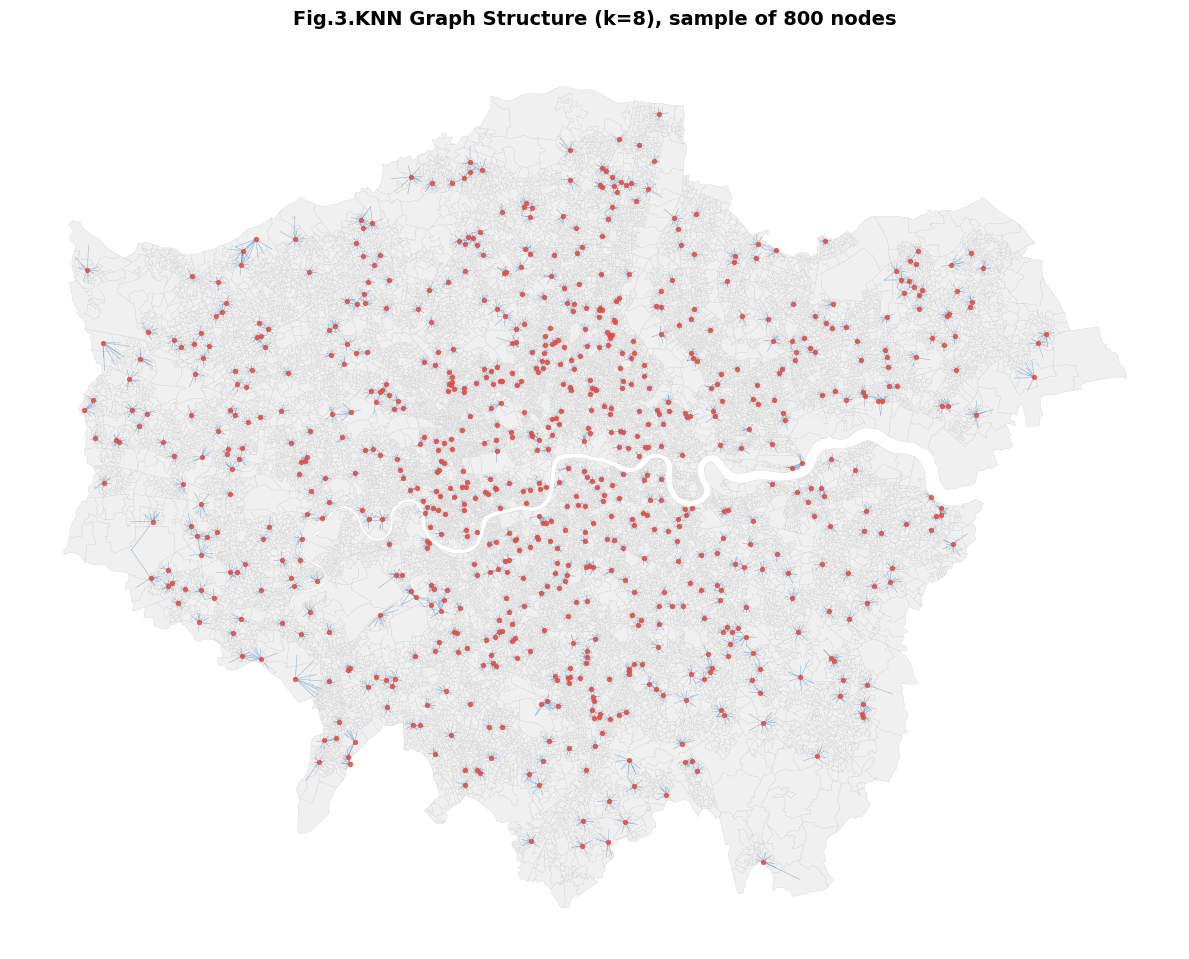

In [9]:
# Visualise the resulting graph structure
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.2)

# Sample 800 nodes for denser display
sample_idx = np.random.choice(len(gdf), 800, replace=False)
sample_set = set(sample_idx)

src, dst = edge_index[0].numpy(), edge_index[1].numpy()
for i in range(len(src)):
    if src[i] in sample_set:
        ax.plot([coords[src[i], 0], coords[dst[i], 0]],
                [coords[src[i], 1], coords[dst[i], 1]],
                color='#4a90d9', linewidth=0.5, alpha=0.5)

ax.scatter(coords[sample_idx, 0], coords[sample_idx, 1],
           s=8, c='#e74c3c', zorder=5, alpha=0.8)

ax.set_title('Fig.3.KNN Graph Structure (k=8), sample of 800 nodes',
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

**Figure 3:** The figure shows a sample of 800 nodes and their KNN connections (k=8) overlaid on the London Output Area boundaries. Each red dot represents an Output Area centroid, and blue lines represent edges connecting each
node to its 8 nearest neighbours.

The graph structure is spatially consistent across the city, with denser connections in central London where Output Areas are smaller and more compact.

###**4. Graph Neural Network Model**

###**4.1** Data Preparation
Before training, node features and target values are standardised using StandardScaler fitted on the training set only, to avoid data leakage.

The dataset is split into training (60%), validation (20%), and test (20%) sets.

In [10]:
def make_masks(num_nodes, train_ratio=0.6, val_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(num_nodes)
    rng.shuffle(idx)
    n_train = int(train_ratio * num_nodes)
    n_val = int(val_ratio * num_nodes)
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[idx[:n_train]] = True
    val_mask[idx[n_train:n_train+n_val]] = True
    test_mask[idx[n_train+n_val:]] = True
    return train_mask, val_mask, test_mask

In [11]:
from sklearn.preprocessing import StandardScaler

# Prepare feature matrix X
X_raw = gdf[feature_cols].values.astype(np.float32)
y_raw = gdf['PM25'].values.reshape(-1, 1).astype(np.float32)

# Get train indices first
train_mask_np, val_mask_np, test_mask_np = make_masks(len(gdf))
train_idx = train_mask_np.numpy()

# Fit scaler on training set only, then transform all
scaler = StandardScaler()
scaler.fit(X_raw[train_idx])
X_scaled = scaler.transform(X_raw)
X = torch.tensor(X_scaled, dtype=torch.float32)

# Same for target y
y_scaler = StandardScaler()
y_scaler.fit(y_raw[train_idx])
y_scaled = y_scaler.transform(y_raw)
y = torch.tensor(y_scaled, dtype=torch.float32).view(-1, 1)

# Pack into PyG Data object
data = Data(x=X, edge_index=edge_index, y=y)
data.train_mask, data.val_mask, data.test_mask = train_mask_np, val_mask_np, test_mask_np

print(data)

Data(x=[25053, 60], edge_index=[2, 230100], y=[25053, 1], train_mask=[25053], val_mask=[25053], test_mask=[25053])


###**4.2** Define the Model

#### **Model Architecture**

Two GNN models are implemented for PM2.5 regression:

1. **GCN (Graph Convolutional Network):** aggregates neighbour features using symmetric normalisation, acting as a spatial smoother across the graph.

2. **GraphSAGE:** explicitly concatenates a node's own features with aggregated neighbour features, generally more flexible than GCN.

Both models share the same structure:
1. **Layer 1:** graph convolution (60 → 128 hidden units) + ReLU activation + Dropout (0.2);
2. **Layer 2:** graph convolution (128 → 1), outputs a scalar PM2.5 prediction;
3. Node features: 60 urban attributes (demographics, housing, socio-economic, employment);
4. Graph edges: KNN spatial connections encoding neighbourhood relationships.

In [12]:
# Define the Model
class GCNReg(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim) #The first convolution layer
        self.conv2 = GCNConv(hidden_dim, 1) #The second convolution layer
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class SAGEReg(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=64, dropout=0.2, aggr="mean"):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim, aggr=aggr)
        self.conv2 = SAGEConv(hidden_dim, 1, aggr=aggr)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

###**4.3** Define Training and Testing functions

In [13]:
# Define training and testing functions
def train_node_regression(model, data, lr=0.01, weight_decay=1e-4, epochs=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_rmse, val_rmse = [], []
    for epoch in range(1, epochs+1):
        model.train()
        optimizer.zero_grad()
        pred = model(data.x, data.edge_index).view(-1)
        y = data.y.view(-1)
        loss = F.mse_loss(pred[data.train_mask], y[data.train_mask])
        loss.backward()
        optimizer.step()

        r_train, r_val, _ = evaluate_regression(model, data)
        train_rmse.append(r_train)
        val_rmse.append(r_val)

        if epoch % 50 == 0:
            print(f"epoch {epoch:3d} | loss {loss.item():.4f} | rmse train {r_train:.4f} | val {r_val:.4f}")
    return train_rmse, val_rmse

@torch.no_grad()
def evaluate_regression(model, data):
    model.eval()
    pred = model(data.x, data.edge_index).view(-1)
    y = data.y.view(-1)
    def rmse(mask):
        return torch.sqrt(F.mse_loss(pred[mask], y[mask])).item()
    return rmse(data.train_mask), rmse(data.val_mask), rmse(data.test_mask)

@torch.no_grad()
def evaluate_regression_r2(model, data):
    model.eval()
    pred = model(data.x, data.edge_index).view(-1)
    y = data.y.view(-1)
    def r2(mask):
        y_true = y[mask]
        y_pred = pred[mask]
        ss_res = torch.sum((y_true - y_pred) ** 2)
        ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
        return (1 - ss_res / (ss_tot + 1e-12)).item()
    return r2(data.train_mask), r2(data.val_mask), r2(data.test_mask)

def plot_learning_curve(train_vals, val_vals, title, ylabel):
    plt.figure(figsize=(7, 4))
    plt.plot(train_vals, label="train")
    plt.plot(val_vals, label="val")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

###**4.4** Training Graph Convolutional Network (GCN)

epoch  50 | loss 0.1661 | rmse train 0.4027 | val 0.3985
epoch 100 | loss 0.1487 | rmse train 0.3807 | val 0.3814
epoch 150 | loss 0.1370 | rmse train 0.3657 | val 0.3695
epoch 200 | loss 0.1290 | rmse train 0.3533 | val 0.3594
epoch 250 | loss 0.1233 | rmse train 0.3442 | val 0.3523
epoch 300 | loss 0.1175 | rmse train 0.3361 | val 0.3458
epoch 350 | loss 0.1138 | rmse train 0.3307 | val 0.3419
epoch 400 | loss 0.1112 | rmse train 0.3256 | val 0.3387
epoch 450 | loss 0.1097 | rmse train 0.3205 | val 0.3349
epoch 500 | loss 0.1072 | rmse train 0.3183 | val 0.3346
epoch 550 | loss 0.1054 | rmse train 0.3178 | val 0.3348
epoch 600 | loss 0.1030 | rmse train 0.3109 | val 0.3299
epoch 650 | loss 0.1020 | rmse train 0.3116 | val 0.3319
epoch 700 | loss 0.1025 | rmse train 0.3094 | val 0.3311
epoch 750 | loss 0.0989 | rmse train 0.3057 | val 0.3284
epoch 800 | loss 0.1028 | rmse train 0.3072 | val 0.3313
epoch 850 | loss 0.0981 | rmse train 0.3052 | val 0.3298
epoch 900 | loss 0.0961 | rmse 

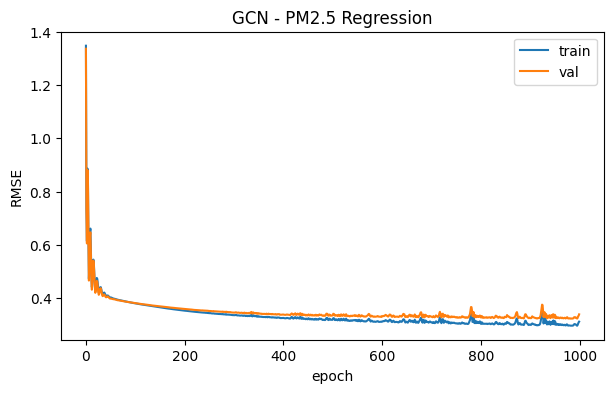

In [14]:
# Training Graph Convolutional Network (GCN)
gcn_reg = GCNReg(in_dim=data.x.size(1), hidden_dim=128, dropout=0.2)
train_rmse_gcn, val_rmse_gcn = train_node_regression(gcn_reg, data, epochs=1000)
print("GCN RMSE  train/val/test:", evaluate_regression(gcn_reg, data))
print("GCN R2    train/val/test:", evaluate_regression_r2(gcn_reg, data))
plot_learning_curve(train_rmse_gcn, val_rmse_gcn, "GCN - PM2.5 Regression", "RMSE")

#### **GCN Training Results**
The GCN model converges steadily over 1000 epochs. The training and validation RMSE curves closely track each other throughout training, indicating no significant overfitting. Both curves drop sharply in the first 100 epochs before gradually stabilising around 0.33-0.35.

| Metric | Train | Validation | Test |
|--------|-------|------------|------|
| RMSE   | 0.312 | 0.339      | 0.343 |
| R²     | 0.903 | 0.881      | 0.875 |

The test R² of 0.875 indicates that the GCN model explains approximately 87.5% of the variance in PM2.5 concentration. The small gap between train and test performance suggests the model generalises well to unseen data.

###**4.5** Training GraphSAGE

epoch  50 | loss 0.1642 | rmse train 0.3957 | val 0.3965
epoch 100 | loss 0.1388 | rmse train 0.3626 | val 0.3733
epoch 150 | loss 0.1221 | rmse train 0.3402 | val 0.3589
epoch 200 | loss 0.1108 | rmse train 0.3242 | val 0.3500
epoch 250 | loss 0.1043 | rmse train 0.3083 | val 0.3393
epoch 300 | loss 0.0963 | rmse train 0.2952 | val 0.3327
epoch 350 | loss 0.0944 | rmse train 0.2997 | val 0.3394
epoch 400 | loss 0.0869 | rmse train 0.2832 | val 0.3308
epoch 450 | loss 0.0899 | rmse train 0.2749 | val 0.3293
epoch 500 | loss 0.0840 | rmse train 0.2795 | val 0.3358
epoch 550 | loss 0.0799 | rmse train 0.2605 | val 0.3254
epoch 600 | loss 0.0771 | rmse train 0.2614 | val 0.3317
epoch 650 | loss 0.0705 | rmse train 0.2432 | val 0.3203
epoch 700 | loss 0.0711 | rmse train 0.2408 | val 0.3216
epoch 750 | loss 0.0670 | rmse train 0.2374 | val 0.3223
epoch 800 | loss 0.0740 | rmse train 0.2654 | val 0.3462
epoch 850 | loss 0.0647 | rmse train 0.2404 | val 0.3300
epoch 900 | loss 0.0740 | rmse 

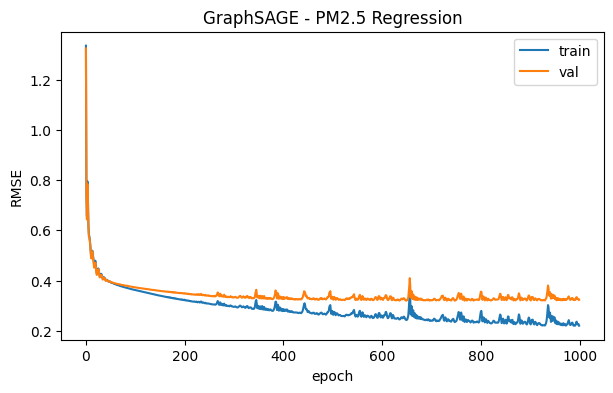

In [15]:
sage_reg = SAGEReg(in_dim=data.x.size(1), hidden_dim=128, dropout=0.2, aggr="mean")
train_rmse_sage, val_rmse_sage = train_node_regression(sage_reg, data, epochs=1000)
print("GraphSAGE RMSE  train/val/test:", evaluate_regression(sage_reg, data))
print("GraphSAGE R2    train/val/test:", evaluate_regression_r2(sage_reg, data))
plot_learning_curve(train_rmse_sage, val_rmse_sage, "GraphSAGE - PM2.5 Regression", "RMSE")

####**GraphSAGE Training Results**

| Metric | Train | Validation | Test |
|--------|-------|------------|------|
| RMSE   | 0.220 | 0.323      | 0.331 |
| R²     | 0.951 | 0.892      | 0.883 |

The GraphSAGE model achieves a slightly higher train R² (0.951) compared to GCN (0.903), however the validation RMSE curve shows noticeable instability with periodic spikes throughout training. The growing gap between train and validation RMSE after epoch 400 suggests mild overfitting, where the model increasingly fits the training data at the expense of generalisation.

Despite this, the test R² of 0.883 remains competitive with GCN (0.875), indicating both models achieve similar generalisation performance on unseen data.

###**4.6** Baseline Comparison

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Prepare numpy arrays for sklearn
X_np = X_scaled
y_np = y_scaled.ravel()

train_idx = data.train_mask.numpy()
test_idx = data.test_mask.numpy()

X_train, X_test = X_np[train_idx], X_np[test_idx]
y_train, y_test = y_np[train_idx], y_np[test_idx]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression:")
print(f"  RMSE: {mean_squared_error(y_test, y_pred_lr)**0.5:.4f}")
print(f"  R2:   {r2_score(y_test, y_pred_lr):.4f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest:")
print(f"  RMSE: {mean_squared_error(y_test, y_pred_rf)**0.5:.4f}")
print(f"  R2:   {r2_score(y_test, y_pred_rf):.4f}")

Linear Regression:
  RMSE: 0.4809
  R2:   0.7539

Random Forest:
  RMSE: 0.4425
  R2:   0.7916


#### **Model Comparison**

| Model | Test RMSE | Test R² |
|-------|-----------|---------|
| Linear Regression | 0.481 | 0.754 |
| Random Forest | 0.443 | 0.792 |
| GCN | 0.343 | 0.875 |
| GraphSAGE | 0.331 | 0.883 |

Both GNN models substantially outperform the baseline models. Linear Regression achieves an R² of 0.754, suggesting that the relationship between urban features and PM2.5 is not purely linear. Random Forest improves upon this (R² = 0.792) by capturing non-linear feature interactions, but still falls short of the GNN models.

The superior performance of GCN and GraphSAGE demonstrates that incorporating spatial relationships through graph edges provides significant predictive value beyond the node features alone. This confirms that PM2.5 concentration is not only determined by local urban characteristics, but also strongly influenced by neighbouring areas, a spatial
spillover effect that only GNNs can explicitly model.

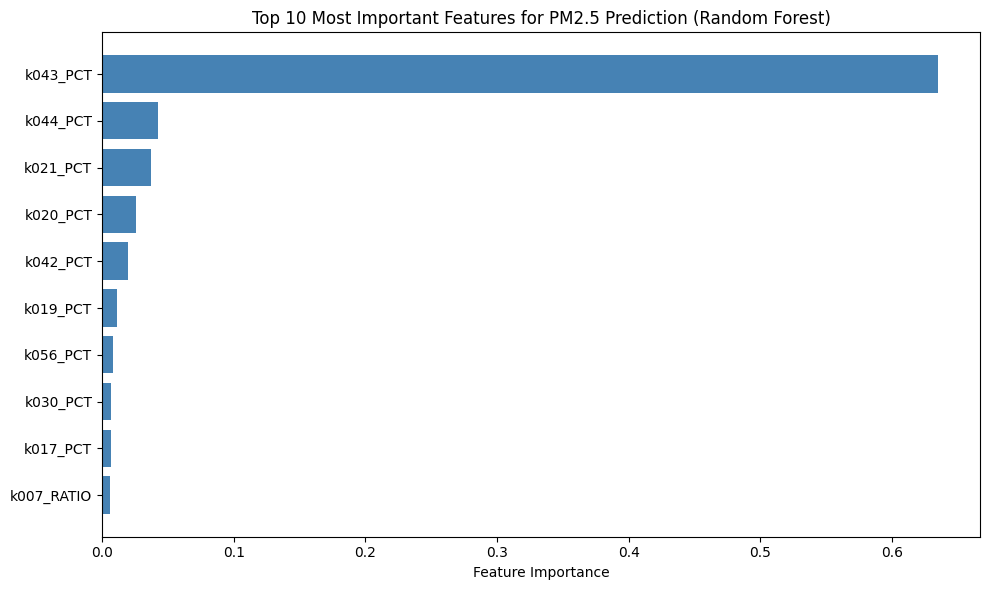

In [18]:
# Feature importance from Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # Top 10 features

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(10), importances[indices][::-1], color='steelblue')
ax.set_yticks(range(10))
ax.set_yticklabels([feature_cols[i] for i in indices][::-1])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 10 Most Important Features for PM2.5 Prediction (Random Forest)')
plt.tight_layout()
plt.show()

#### **Feature Importance Analysis**

The Random Forest feature importance reveals that **k043 (Private Transport)** is by far the most influential predictor of PM2.5 concentration (importance > 0.6), which is highly intuitive, areas with higher private car usage directly contribute to vehicle emissions and therefore higher pollution levels.

The next most important features are **k044 (On foot, Bicycle or Other)** and **k042 (Public transport)**, which together with k043 represent the complete modal split of commuting behaviour. This suggests that travel behaviour is the dominant driver of PM2.5 variation across London Output Areas.

Demographic features such as **k020 (United Kingdom & Ireland)**, **k021 (Other EU: Member countries in March
2001)**, and **k019 (Arab/other ethnic groups)** also appear in the top 10, likely acting as proxies for residential location patterns, with certain ethnic communities concentrated in high-density, high-pollution central areas.

**k007 (Population density)** and **k030 (Flats)** further reflect urban density, consistent with the spatial pattern observed in the PM2.5 map where central London shows highest pollution levels.

##**5. Results and Interpretation**

###**5.1** Prediction vs. Actual plot

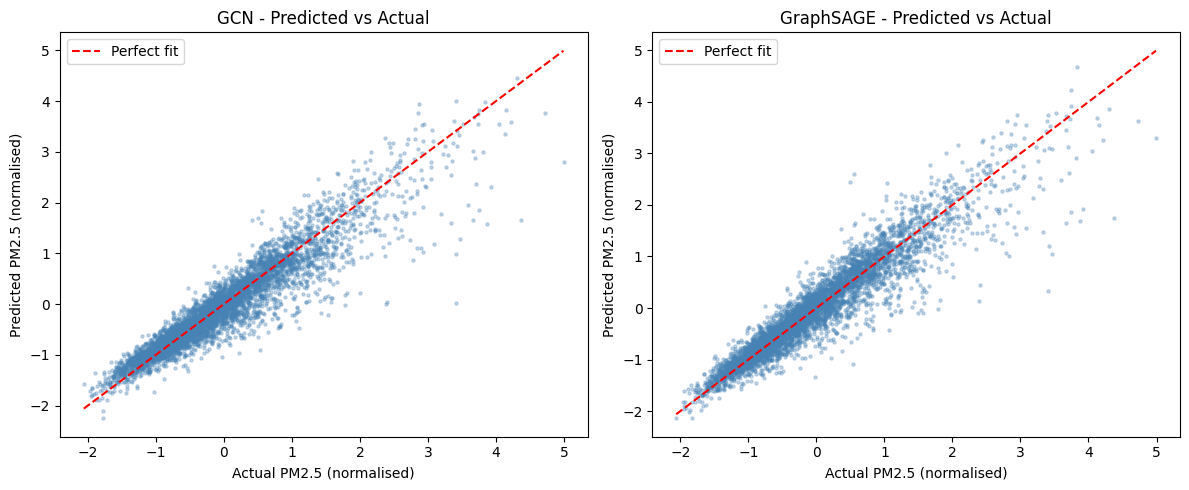

In [19]:
@torch.no_grad()
def get_predictions(model, data):
    model.eval()
    return model(data.x, data.edge_index).view(-1).cpu().numpy()

test_mask_np = data.test_mask.numpy()
y_true = data.y.view(-1).cpu().numpy()[test_mask_np]
pred_gcn = get_predictions(gcn_reg, data)[test_mask_np]
pred_sage = get_predictions(sage_reg, data)[test_mask_np]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title in zip(axes, [pred_gcn, pred_sage], ['GCN', 'GraphSAGE']):
    ax.scatter(y_true, pred, alpha=0.3, s=5, color='steelblue')
    mn, mx = y_true.min(), y_true.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual PM2.5 (normalised)')
    ax.set_ylabel('Predicted PM2.5 (normalised)')
    ax.set_title(f'{title} - Predicted vs Actual')
    ax.legend()
plt.tight_layout()
plt.show()

Both models show strong alignment between predicted and actual values, with points closely following the perfect fit line (red dashed), consistent with the high R² scores (GCN: 0.875, GraphSAGE: 0.883).

However, both models show a tendency to **underestimate extreme high values** (actual PM2.5 > 3 in normalised scale), points in the upper right region fall below the perfect fit line. This is expected given the right-skewed distribution observed in Figure 1, where very high pollution values are rare and therefore underrepresented in the training data.

Both models perform similarly in terms of visual prediction quality, with GraphSAGE achieving a marginally higher R² (0.883 vs 0.875).

###**5.2** The map of Predicted PM2.5 Values

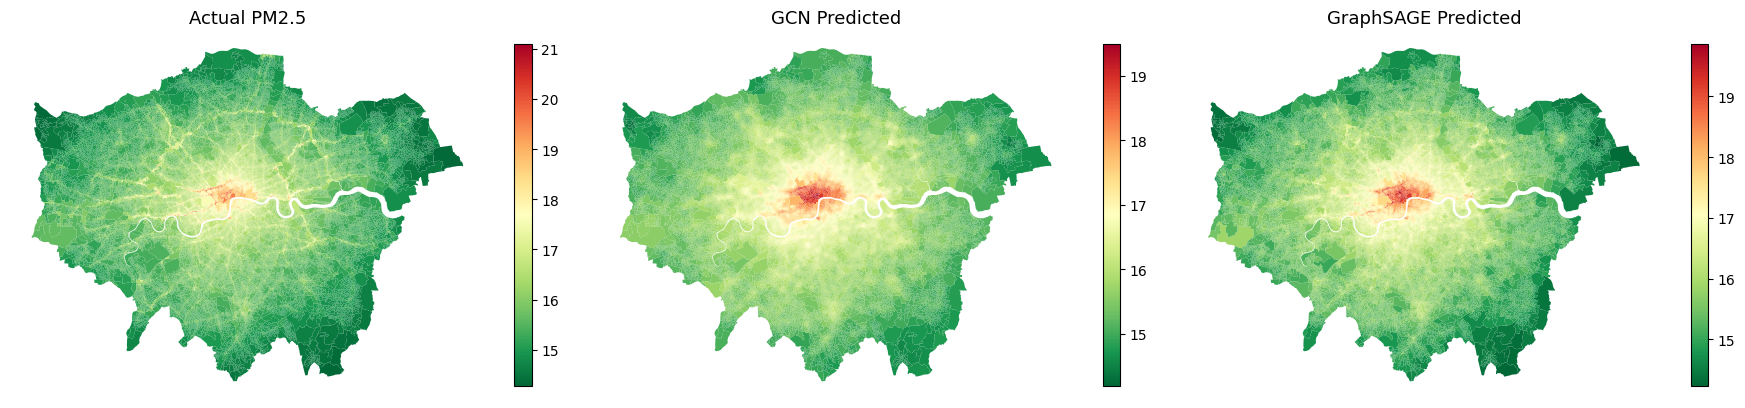

In [20]:
gdf_plot = gdf.copy()
all_preds_gcn = get_predictions(gcn_reg, data)
all_preds_sage = get_predictions(sage_reg, data)

gdf_plot['pred_gcn'] = y_scaler.inverse_transform(all_preds_gcn.reshape(-1,1))
gdf_plot['pred_sage'] = y_scaler.inverse_transform(all_preds_sage.reshape(-1,1))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col, title in zip(axes,
    ['PM25', 'pred_gcn', 'pred_sage'],
    ['Actual PM2.5', 'GCN Predicted', 'GraphSAGE Predicted']):
    gdf_plot.plot(column=col, cmap='RdYlGn_r', legend=True, ax=ax,
                  legend_kwds={'shrink': 0.6})
    ax.set_title(title, fontsize=13)
    ax.axis('off')
plt.tight_layout()
plt.show()

Both GCN and GraphSAGE successfully reproduce the overall spatial pattern of PM2.5 across London, capturing the clear centre-periphery gradient observed in the actual map. The high pollution cluster in central London and the gradual decrease towards outer boroughs are well-represented in both predictions.

However, both models **underestimate the peak pollution values** in the city centre, Which means the actual map reaches 21 μg/m³ while GCN and GraphSAGE predictions peak at
approximately 19 μg/m³. This is consistent with the scatter plot analysis in 5.1, where extreme high values tend to be underestimated.

The predicted maps also appear **slightly smoother** than the actual map, with less fine-grained local variation. This is a known characteristic of GNN models, where message passing between neighbours tends to average out local extremes (a phenomenon known as over-smoothing).

###**5.3** GCN Prediction Error Distribution

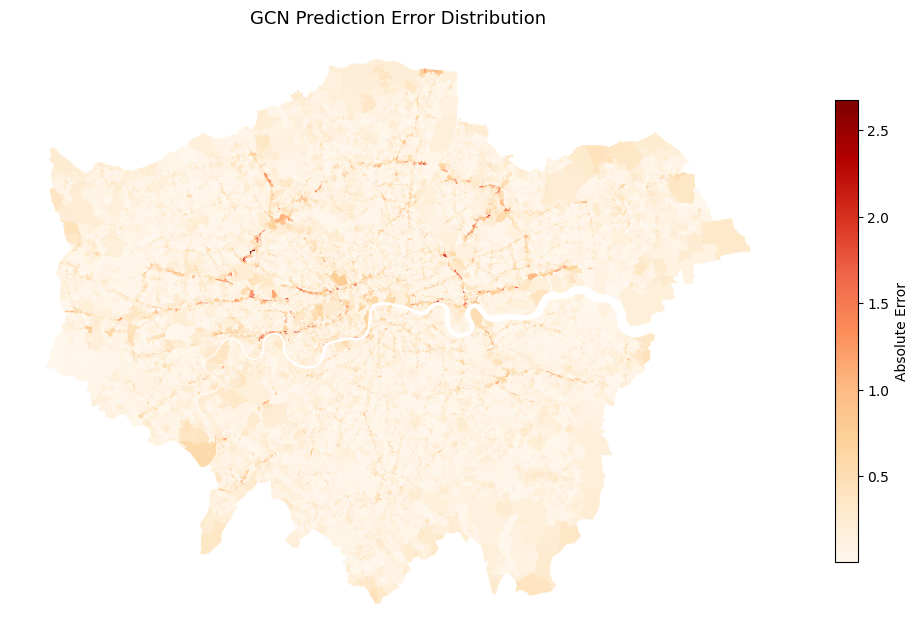

In [23]:
gdf_plot['error_gcn'] = np.abs(
    gdf_plot['PM25'] - gdf_plot['pred_gcn']
)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_plot.plot(column='error_gcn', cmap='OrRd', legend=True, ax=ax,
              legend_kwds={'label': 'Absolute Error', 'shrink': 0.6})
ax.set_title('GCN Prediction Error Distribution', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

The error map reveals that prediction errors are not randomly distributed across London, but show clear spatial patterns.

The highest errors (dark red, absolute error > 2.0) are concentrated along **major road corridors** in central and inner London, particularly along arterial routes and near the Thames. These are areas where PM2.5 is driven by highly localised traffic emissions that may not be fully captured by the census-based socio-economic features alone.

In contrast, outer suburban areas show consistently low errors (light beige, absolute error < 0.5), where PM2.5 levels are more uniform and easier to predict from neighbourhood characteristics.

##**6. Discussion and Reflection**

###**6.1** Discussion:
*--where the model performs well or poorly?*

The GNN models perform well in suburban and outer London areas, where PM2.5 concentrations are relatively uniform and spatial patterns are smooth. In these regions, the socio-economic features (particularly transport behaviour k043, k044) combined with neighbourhood aggregation through graph edges are sufficient to capture pollution levels accurately.

The models struggle with highly localised pollution hotspots along major road corridors in central London, as shown in the error map (Section 5.3). These areas have sharp, fine-grained PM2.5 variations driven by point-source emissions such as heavy traffic intersections, which cannot be captured by area-level census features or smoothed KNN graph connections.

###**6.2** Reflection
*--the role of spatial relationships in prediction*

The comparison between GNN models and baseline models clearly demonstrates the importance of spatial relationships. Linear Regression and Random Forest rely solely on each node's own features, achieving R² of 0.754 and 0.792 respectively. In contrast, GCN and GraphSAGE aggregate information from neighbouring Output Areas via graph edges, achieving R² of 0.875 and 0.883. This improvement confirms that PM2.5 concentration exhibits strong spatial autocorrelation, reflecting the physical diffusion of air pollutants across space.

*--potential limitations of the approach*

1. **Feature limitation:** Node features are derived from the 2011 census, which may not accurately reflect current urban conditions. Direct traffic volume or emissions data would likely improve prediction accuracy, especially for road corridor hotspots.
2. **Graph construction:** The KNN graph connects nodes purely by Euclidean distance, ignoring physical barriers such as the Thames or actual road network topology. A road network-based graph might better represent how pollution propagates.
3. **Spatial data leakage:** Although the train/val/test split is random, spatially adjacent nodes may appear in both training and test sets, potentially inflating performance metrics. A spatial block cross-validation strategy would
provide a more rigorous evaluation.
4. **Over-smoothing:** GNN message passing tends to average neighbourhood features, which smooths out localised pollution extremes and contributes to the underestimation
of peak PM2.5 values observed in central London.

###**Github linking:**
https://github.com/KeerSG/ATUA_Keer